### Optimal control of the Wilson-Cowan model
This notebook shows how to compute the optimal control (OC) signal for the Wilson-Cowan model for a simple example task.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

while os.getcwd().split(os.sep)[-1] != "neurolib":
    os.chdir('..')

# We import the model, stimuli, and the optimal control package
from neurolib.models.lin_osc import LinOscModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_linosc

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

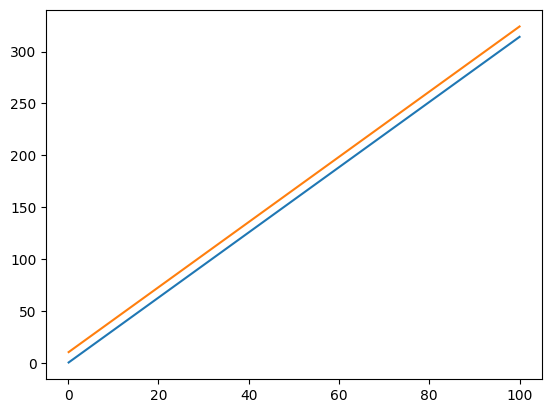

In [21]:
# We import the model
model = LinOscModel()

# Some parameters to define stimulation signals
dt = model.params["dt"]
duration = 100.
amplitude = 1.
period = duration

# We define a "zero-input", and a sine-input
zero_input = ZeroInput().generate_input(duration=duration+dt, dt=dt)
input = np.copy(zero_input)
#input[0,1:-1] = amplitude * np.sin(2.*np.pi*np.arange(0,duration-0.1, dt)/period) # other functions or random values can be used as well

# We set the duration of the simulation and the initial values
model.params["duration"] = duration
theta_init = 0.
model.params["theta_init"] = np.array([[theta_init]])
model.params.sigma_ou = 0.
model.run()

target = np.zeros((1, 1, len(model.t)+1))
target[0,0,1:] = model.theta[0,:]
target[0,0,:] += 10.

plt.plot(model.t, model.theta[0,:])
plt.plot(model.t, target[0,0,1:])
plt.show()


In [22]:
costmat = np.zeros((1,2))
costmat[0,0] = 1

# We load the optimal control class
# print array (optional parameter) defines, for which iterations intermediate results will be printed
# Parameters will be taken from the input model
model_controlled = oc_linosc.OcLinosc(model, target, print_array=np.arange(0,501,25), control_interval=(0,None), cost_interval=(0,None), cost_matrix=costmat, M=1)
model_controlled.weights["w_p"] = 1. # default value 1
model_controlled.weights["w_2"] = 1. # default value 0

# We run 500 iterations of the optimal control gradient descent algorithm
model_controlled.optimize(100)

state = model_controlled.get_xs()
control = model_controlled.control

Optimal control with target time series
Compute control for a deterministic system
Cost in iteration 0: 5005.0
Cost in iteration 25: 182.061848103712
Cost in iteration 50: 130.39257600946436
Cost in iteration 75: 108.95547961335703
Cost in iteration 100: 96.72894042929862
Final cost : 96.72894042929862


Compute control for a deterministic system
Cost in iteration 0: 57.60220134599695
Cost in iteration 25: 57.26851729042408
Cost in iteration 50: 56.96092160992306
Cost in iteration 75: 56.65533608271464
Cost in iteration 100: 56.3982045223284
Cost in iteration 125: 56.15916381075441
Cost in iteration 150: 55.92904656827502
Cost in iteration 175: 55.715148744133764
Cost in iteration 200: 55.52921557727696
Cost in iteration 225: 55.3519706655445
Cost in iteration 250: 55.186216640863336
Cost in iteration 275: 55.037075706920504
Cost in iteration 300: 54.885767941480616
Cost in iteration 325: 54.75692576111342
Cost in iteration 350: 54.63557934434077
Cost in iteration 375: 54.51732903461912
Cost in iteration 400: 54.40606265619783
Cost in iteration 425: 54.30614505637973
Cost in iteration 450: 54.21401114074912
Cost in iteration 475: 54.125111759700474
Cost in iteration 500: 54.04389167471113
Final cost : 54.04389167471113


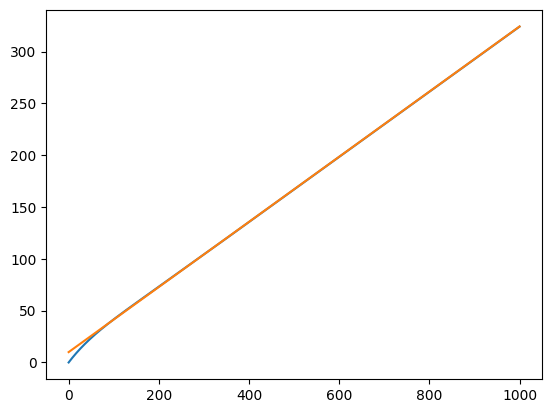

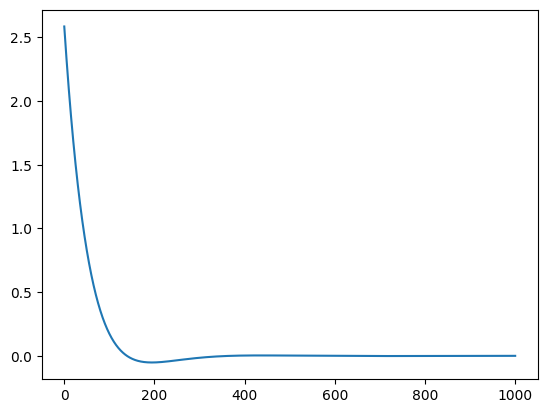

In [24]:
model_controlled.optimize(500)

plt.plot(state[0,0,:])
plt.plot(target[0,0,:])
plt.show()

plt.plot(control[0,0,:])
plt.show()
